# 04 - Autograd from scratch

In notebook 03 we worked out the gradient of a one-layer model by hand. That approach does not scale, because a real network is a deep chain of thousands of operations, and differentiating all of it by hand is hopeless. The solution is **automatic differentiation**, usually shortened to **autograd**. It is the machinery behind the `loss.backward()` call in PyTorch.

The idea is small and rather elegant: build an expression out of tiny operations, have each operation remember how it was computed, then sweep backward through the chain applying a single rule, the chain rule, to obtain the gradient of everything at once. We will build a working engine for ordinary numbers in about 40 lines. After this, `.backward()` will no longer feel mysterious.

## The chain rule, the only rule

Everything below rests on one fact from calculus, and it has a friendly picture.

Think of exchange rates. Suppose 1 dollar is worth 3 euros, and 1 euro is worth 2 pesos. How many pesos is a dollar worth? You multiply the rates: `3 * 2 = 6`. The chain rule is that same move applied to "sensitivities." If nudging `a` changes `b` at a rate written `db/da`, and nudging `b` changes the loss `L` at a rate written `dL/db`, then nudging `a` changes `L` at the product of the two:

$$\frac{dL}{da} = \frac{dL}{db}\cdot\frac{db}{da}$$

(The notation `dL/da` simply means "the rate at which `L` changes when `a` changes," which is the slope, or derivative, from notebook 01.) So to find how the loss responds to some number buried deep in the network, you multiply the small rates along the path from that number up to the loss.

How autograd uses this: every operation knows its own small rate, called its **local derivative**, with respect to its inputs. The code comments spell each one out; for `a + b` the rate is 1, and for `a * b` it is the other input. Backprop starts at the output with `dL/dL = 1` and walks backward, and at each step it multiplies the gradient coming in from above by that operation's local rate, handing the correct gradient down to its inputs. That per-operation step is stored as a small `_backward` function.

One subtlety: gradients add up. If a value is used in two places, nudging it affects the loss through both paths, so its total gradient is the sum of what comes back from each. This is why every `grad` starts at 0 and we always add to it, and why `backward()` first sorts the operations into order (a "topological order"), so that each one is finalized only after everything that depends on it has already contributed its gradient.

## Step 1: A number that remembers where it came from

We build the engine in five small steps and run each one before taking the next. One example runs through all of them:

```
a = 2,  b = -3,  c = 10
e = a * b        (so e = -6)
L = e + c        (so L = 4)
```

`L` plays the loss. The question: nudge `a`, `b` or `c`, and how fast does `L` move?

A plain Python number forgets where it came from: `-6` cannot say it was made by multiplying 2 and -3. The first version of `Value` fixes that and nothing else. It does no calculus; it only records.

In [1]:
class Value:
    """A number that remembers how it was made."""
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = _children
        self._op = _op

    def __add__(self, other):
        out = Value(self.data + other.data,
                    (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data,
                    (self, other), '*')
        return out

    def __repr__(self):
        return f"Value(data={self.data})"

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>class Value:</code>: the blueprint. It holds a number plus its history. The triple-quoted line is a <b>docstring</b>, a note for human readers.</li>
<li><code>def __init__(self, data, _children=(), _op=&#x27;&#x27;):</code>: runs when you write <code>Value(2.0)</code>. The last two parameters default to an empty tuple and an empty string, which is right for a <b>leaf</b>: a number you typed in, with no inputs.</li>
<li><code>self._prev = _children</code>: the inputs that produced this value. They are called <b>children</b> because these diagrams are often drawn loss-at-the-top, like a family tree, with inputs hanging underneath.</li>
<li><code>self._op = _op</code>: which operation produced it, e.g. '+' or '*'. Only for inspection.</li>
<li><code>def __add__(self, other):</code>: runs when Python meets <code>x + y</code>, with <code>self</code> as <code>x</code> and <code>other</code> as <code>y</code>.</li>
<li><code>out = Value(self.data + other.data, (self, other), &#x27;+&#x27;)</code>: add the numbers, then wrap the answer in a new <code>Value</code> that records its inputs <code>(self, other)</code> and its label <code>'+'</code>.</li>
<li><code>__mul__</code>: the same shape, with <code>*</code> in place of <code>+</code>.</li>
<li><code>__repr__</code>: what a <code>Value</code> looks like when printed.</li>
</ul>
</details>

In [2]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
e = a * b
L = e + c
print(L)
print(L._op, L._prev)
print(e._op, e._prev)

Value(data=4.0)
+ (Value(data=-6.0), Value(data=10.0))
* (Value(data=2.0), Value(data=-3.0))


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>a, b, c</code>: three leaves.</li>
<li><code>e = a * b</code>: looks like arithmetic, but Python runs <code>a.__mul__(b)</code>, which builds a node holding -6.0 that remembers <code>a</code> and <code>b</code>.</li>
<li><code>L = e + c</code>: the same with <code>+</code>: <code>L</code> remembers <code>e</code> and <code>c</code>.</li>
<li><code>print(L._op, L._prev)</code>: read the receipt back: made by '+' from -6.0 and 10.0. Together these back-links form the <b>computation graph</b>. No gradient has been computed yet.</li>
</ul>
</details>

## Step 2: Sweep the graph with a pencil

First, the backward pass on paper, using the chain rule section's two facts: `+` forwards the incoming gradient untouched (rate 1), and `*` scales it, for each input, by the partner input's value.

1. At `L`: its gradient with respect to itself is 1.
2. The `+` in `L = e + c` forwards that 1: `e.grad = 1`, `c.grad = 1`.
3. The `*` in `e = a * b` receives 1: `a.grad = -3 x 1 = -3`, `b.grad = 2 x 1 = 2`.

Check by nudging: move `a` to 2.01 and `L` becomes -6.03 + 10 = 3.97. A drop of 0.03 per 0.01 of push: rate -3, as predicted.

Every node did one identical thing: scale its own gradient by a local rate and add the result to each input. The local rate is fixed by the operation and its inputs, which are known when the node is built, so each node can be given its rule right then. That is Step 3.

## Step 3: Give every node its own backward rule

Each node's rule will be a tiny function. Three Python facts make this possible; here they are in isolation.

**A function can be stored like a number.**

In [3]:
def say_hi():
    print("hi")

greet = say_hi    # store the function
greet()           # run it

hi


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>greet = say_hi</code>: no brackets: this stores the function under a second name. It does not run it.</li>
<li><code>greet()</code>: the brackets run it, printing <code>hi</code>. With or without brackets is the difference between storing a rule and running it.</li>
</ul>
</details>

**A function made inside a function remembers what it saw.** Such a function is called a **closure**.

In [4]:
def make_rule(rate):
    def rule(arriving):
        return rate * arriving
    return rule

times_three = make_rule(3)
print(times_three(10))
print(times_three(0.5))

30
1.5


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def rule(arriving):</code>: a function defined inside <code>make_rule</code>; it multiplies whatever arrives by <code>rate</code>.</li>
<li><code>return rule</code>: hand back the inner function without running it.</li>
<li><code>times_three = make_rule(3)</code>: <code>make_rule</code> runs once with <code>rate</code> = 3 and finishes. We keep <code>rule</code>.</li>
<li><code>times_three(10)</code>: <code>rule</code> still knows <code>rate</code> is 3, so this prints 30, and <code>times_three(0.5)</code> prints 1.5. A stored rate that multiplies what arrives: one step of the chain rule.</li>
</ul>
</details>

**A function reads a value when it runs, not when it was written.**

In [5]:
box = Value(1.0)

def peek():
    return box.data

box.data = 5.0
print(peek())

5.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def peek():</code>: written while <code>box.data</code> is 1.0.</li>
<li><code>box.data = 5.0</code>: change the number before <code>peek</code> ever runs.</li>
<li><code>print(peek())</code>: prints 5.0: <code>peek</code> looks the value up when it runs. A backward rule is written when its node is made and runs later, once the gradient has arrived; it reads that gradient as it is then.</li>
</ul>
</details>

### The class, second version

Two new slots, `grad` and `_backward`, and a rule inside `__add__` and `__mul__`. The changes from Step 1 are marked `# new`.

In [6]:
class Value:
    """A number that remembers how it was made."""
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0                  # new
        self._backward = lambda: None    # new
        self._prev = _children
        self._op = _op

    def __add__(self, other):
        out = Value(self.data + other.data,
                    (self, other), '+')
        def _backward():                 # new
            self.grad  += out.grad       # new
            other.grad += out.grad       # new
        out._backward = _backward        # new
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data,
                    (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __repr__(self):
        return (f"Value(data={self.data:.4f}, "
                f"grad={self.grad:.4f})")

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>self.grad = 0.0</code>: where the sweep will leave this node's gradient; zero until then.</li>
<li><code>self._backward = lambda: None</code>: this node's backward rule. A leaf has no inputs, so its rule does nothing; every operation replaces it.</li>
<li><code>def _backward():</code>: the rule for this one operation, defined inside it, so it is a closure that remembers <code>self</code>, <code>other</code> and <code>out</code>.</li>
<li><code>self.grad += out.grad</code>: for <code>+</code> the local rate is 1, so both inputs get <code>out.grad</code> as it is. <code>out.grad</code> is read when the rule runs.</li>
<li><code>+=</code>: add to what is already there, so a value used in two places collects a share from each.</li>
<li><code>out._backward = _backward</code>: no brackets: store the rule on the result node for later. <code>_backward()</code> would run it now, while <code>out.grad</code> is still 0.</li>
<li><code>self.grad += other.data * out.grad</code>: for <code>*</code>, an input's share is its partner's value multiplied by <code>out.grad</code>.</li>
<li><code>__repr__</code>: now prints the gradient too, with four digits after the point.</li>
</ul>
</details>

### Run the rules by hand

No sweep exists yet, so trigger the rules manually, in the same order as on paper: set `L.grad` to 1, then `L._backward()`, then `e._backward()`.

In [7]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
e = a * b
L = e + c
print("before :", a.grad, b.grad, c.grad)
L.grad = 1.0
L._backward()
print("after L:", e.grad, c.grad)
e._backward()
print("after e:", a.grad, b.grad)

before : 0.0 0.0 0.0
after L: 1.0 1.0
after e: -3.0 2.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>a = Value(2.0) ... L = e + c</code>: a fresh graph built from the new class: all gradients zero, every node carrying a rule.</li>
<li><code>L.grad = 1.0</code>: start the sweep: dL/dL is 1.</li>
<li><code>L._backward()</code>: runs the rule <code>__add__</code> stored on <code>L</code>: 1 to <code>e</code> and to <code>c</code>.</li>
<li><code>e._backward()</code>: runs the rule <code>__mul__</code> stored on <code>e</code>: -3 to <code>a</code>, 2 to <code>b</code>. The pencil's numbers exactly.</li>
</ul>
</details>

### The order is not a detail

What if `e._backward()` goes first, before anything has set `e.grad`? Try it on a freshly built graph.

In [8]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
e = a * b
L = e + c
L.grad = 1.0
e._backward()      # wrong: e before L
L._backward()
print("a.grad =", a.grad, " b.grad =", b.grad)
print("e.grad =", e.grad)

a.grad = 0.0  b.grad = 0.0
e.grad = 1.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>e._backward()</code>: runs while <code>e.grad</code> is still 0, so it hands -3 x 0 and 2 x 0 to <code>a</code> and <code>b</code>.</li>
<li><code>L._backward()</code>: fills in <code>e.grad</code> correctly, but too late. No error, no warning: two zeros that read as "this input does not matter." So a node must wait until all of its users have handed their shares down before it hands on its own.</li>
</ul>
</details>

## Step 4: Let the computer find the order

Put the nodes in a list where **inputs always appear before whatever they feed** (socks before shoes), then read the list backwards. Such a list is a **topological order**. `build` makes it by recursion: before listing a node, list its inputs.

In [9]:
def topo_order(root):
    order, visited = [], set()
    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            order.append(v)
    build(root)
    return order

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>order, visited = [], set()</code>: a list to fill and a set to remember which nodes are already handled.</li>
<li><code>def build(v):</code>: the procedure for one node, a closure over <code>order</code> and <code>visited</code>.</li>
<li><code>if v not in visited: visited.add(v)</code>: handle each node once, even when two paths reach it.</li>
<li><code>for child in v._prev: build(child)</code>: the recursion: list every input first.</li>
<li><code>order.append(v)</code>: only then list <code>v</code> itself.</li>
<li><code>build(root); return order</code>: start at the final node and return the finished list.</li>
</ul>
</details>

In [10]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
e = a * b
L = e + c
print([v.data for v in topo_order(L)])

[2.0, -3.0, -6.0, 10.0, 4.0]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>topo_order(L)</code>: gives a, b, e, c, L: inputs always before the node they feed.</li>
<li><code>[v.data for v in ...]</code>: a list comprehension printing each node's number so you can recognize it.</li>
</ul>
</details>

In [11]:
L.grad = 1.0
for v in reversed(topo_order(L)):
    v._backward()
print("a.grad =", a.grad, " b.grad =", b.grad,
      " c.grad =", c.grad)

a.grad = -3.0  b.grad = 2.0  c.grad = 1.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>reversed(topo_order(L))</code>: visits L, c, e, b, a, so users always come before the nodes they use.</li>
<li><code>v._backward()</code>: <code>L</code>'s and <code>e</code>'s rules do the work; the leaves' rules do nothing. The pencil's answers, and nobody chose the order by hand.</li>
</ul>
</details>

## Step 5: Finish the engine and check it

New in this version: `backward()` becomes a method, operations accept bare numbers like `1` or `2`, there are rules for `**` and `tanh`, and `-` and `/` are defined through `+`, `*` and `**`, which already carry rules. This is the class the rest of the notebook uses.

In [12]:
import math

class Value:
    """A number that remembers how it was made."""
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = _children
        self._op = _op

    def __add__(self, other):
        if not isinstance(other, Value):     # new
            other = Value(other)             # new
        out = Value(self.data + other.data,
                    (self, other), '+')
        def _backward():
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        if not isinstance(other, Value):     # new
            other = Value(other)             # new
        out = Value(self.data * other.data,
                    (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):
        out = Value(self.data ** k, (self,), f'**{k}')
        def _backward():
            # rate = k * a**(k-1)
            self.grad += k * self.data**(k-1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            # rate = 1 - t**2
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        self.grad = 1.0
        for v in reversed(topo_order(self)):
            v._backward()

    def __neg__(self):
        return self * -1
    def __radd__(self, o):
        return self + o
    def __sub__(self, o):
        return self + (-o)
    def __rsub__(self, o):
        return o + (-self)
    def __rmul__(self, o):
        return self * o
    def __truediv__(self, o):
        return self * o ** -1
    def __repr__(self):
        return (f"Value(data={self.data:.4f}, "
                f"grad={self.grad:.4f})")

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import math</code>: Python's math toolbox, for <code>tanh</code>.</li>
<li><code>if not isinstance(other, Value): other = Value(other)</code>: bare numbers such as the 1 in <code>a + 1</code> get wrapped so every node in the graph is a <code>Value</code>.</li>
<li><code>def __pow__(self, k):</code>: <code>a ** k</code> for a plain number <code>k</code>. Its local rate is the power rule, <code>k * a**(k-1)</code>. <code>(self,)</code> is a one-item tuple: the comma makes the tuple.</li>
<li><code>def tanh(self):</code>: squashes any number into -1..1. Its local rate is <code>1 - t**2</code>; the rule reuses the remembered <code>t</code> rather than recomputing it.</li>
<li><code>def backward(self):</code>: the three sweep lines from Step 4 as a method, using <code>topo_order</code>, which keeps the ordering code in a single spot.</li>
<li><code>__neg__, __sub__, __truediv__</code>: <code>-a</code> is <code>a * -1</code>, <code>a - b</code> is <code>a + (-b)</code>, <code>a / b</code> is <code>a * b**-1</code>: built from operations that already have rules.</li>
<li><code>__radd__, __rsub__, __rmul__</code>: the <b>reflected</b> versions: Python asks the right operand when the left one, a plain number, cannot handle a <code>Value</code>. Without them <code>2 * a</code> fails while <code>a * 2</code> works.</li>
</ul>
</details>

### Why `__rmul__` and friends exist

The class defines `__radd__`, `__rsub__` and `__rmul__` alongside the ordinary ones. The `r` stands for **reflected**, and they exist because of the order Python resolves an operator in. Meeting `2 * a`, it asks the *left* operand first: "int, can you multiply yourself by this thing?" An `int` has never heard of a `Value`, so it declines, and only then does Python turn to the right-hand operand and ask the mirrored question through `__rmul__`. Leave them out and `a * 2` works while `2 * a` fails.

The operand order inside `__rsub__` matters too. There, `self` is the `Value` and `o` is the number on the *left*, so `2 - a` has to come out as `2 + (-a)`. The other way round quietly computes `a - 2` — the negation of the right answer.

In [13]:
a = Value(3.0)
print("a * 2 uses __mul__  ->", (a * 2).data)
print("2 * a uses __rmul__ ->", (2 * a).data)
print("2 - a should be -1.0")
print("  o + (-self) gives ->", (2 - a).data)
print("  self - o would be ->", (a + (-2)).data)
print("sum([a, a]) uses __radd__ ->",
      sum([a, a]).data)

a * 2 uses __mul__  -> 6.0
2 * a uses __rmul__ -> 6.0
2 - a should be -1.0
  o + (-self) gives -> -1.0
  self - o would be -> 1.0
sum([a, a]) uses __radd__ -> 6.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>(a * 2).data and (2 * a).data</code>: both give 6.0, but by different routes: the first through <code>__mul__</code>, the second through <code>__rmul__</code> after <code>int</code> declined.</li>
<li><code>(2 - a).data</code>: <code>-1.0</code>, which is what <code>2 - 3</code> should be.</li>
<li><code>(a + (-2)).data</code>: <code>1.0</code> &mdash; what the wrong operand order would have produced. Both look like valid answers and neither raises an error, but only -1.0 is correct.</li>
<li><code>sum([a, a])</code>: <code>sum</code> begins with a plain 0, and <code>0 + a</code> can only be handled by <code>__radd__</code>. The neural net below adds up lists of <code>Value</code>s this way.</li>
</ul>
</details>

One `backward()` call on the running example reproduces the paper sweep:

In [14]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
L = a * b + c
L.backward()
print(a.grad, b.grad, c.grad)

-3.0 2.0 1.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>L.backward()</code>: seeds <code>L</code> with 1 and runs every rule in the order <code>topo_order</code> gives. Prints -3.0 2.0 1.0, the pencil's numbers.</li>
</ul>
</details>

### A value used twice

Why `+=` and not `=`? Because of values like this, used in two places:

In [15]:
z = Value(3.0)
M = z * z
print(M._prev[0] is M._prev[1])
M.backward()
print("z.grad =", z.grad)

True
z.grad = 6.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>M._prev[0] is M._prev[1]</code>: <code>is</code> asks "are these the very same object?" True: both inputs of this multiplication are <code>z</code>.</li>
<li><code>M.backward()</code>: <code>topo_order</code> lists <code>z</code> once, thanks to <code>visited</code>, so <code>M</code>'s rule runs once.</li>
<li><code>print(&quot;z.grad =&quot;, z.grad)</code>: that one rule adds 3 for <code>self</code> and 3 more for <code>other</code>, both <code>z</code>: 6.0, the slope of z&sup2; at z = 3. With <code>=</code> instead of <code>+=</code> the second would overwrite the first and leave 3.0. <code>visited</code> keeps the <i>walk</i> to once per node; <code>+=</code> counts every <i>use</i>.</li>
</ul>
</details>

### When one value is used twice

`M = z * z` is the smallest case, but it hides something: both paths leave from the *same* operation. Real fan-out looks like this, where `a` feeds two different operations that meet again at the end:

```
      b = a * 2
    /           \
a                 L = b * c
    \           /
      c = a + 5
```

Nudging `a` moves `L` along **both** routes, so `a.grad` has to be the sum of what comes back along each.

In [16]:
a = Value(3.0)
b = a * 2           # route 1
c = a + 5           # route 2
L = b * c
L.backward()

print("forward:  b =", b.data, " c =", c.data, " L =", L.data)
print("b.grad =", b.grad, "  c.grad =", c.grad)
print("route 1 into a:", b.grad, "x 2 =", b.grad * 2)
print("route 2 into a:", c.grad, "x 1 =", c.grad * 1)
print("a.grad =", a.grad)


forward:  b = 6.0  c = 8.0  L = 48.0
b.grad = 8.0   c.grad = 6.0
route 1 into a: 8.0 x 2 = 16.0
route 2 into a: 6.0 x 1 = 6.0
a.grad = 22.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>b = a * 2 / c = a + 5</code>: two different operations reading the same <code>a</code>. That is the fan-out; a plain chain never does this.</li>
<li><code>b.grad = 8.0</code>: the gradient that reached <code>b</code>. <code>L = b &times; c</code>, so the local rate toward <code>b</code> is the <i>other</i> input, <code>c</code> = 8.</li>
<li><code>c.grad = 6.0</code>: same rule at the same node: the rate toward <code>c</code> is <code>b</code> = 6.</li>
<li><code>route 1 into a</code>: carry 8 back through <code>b = a &times; 2</code>, whose local rate toward <code>a</code> is 2: 8 &times; 2 = <b>16</b>.</li>
<li><code>route 2 into a</code>: carry 6 back through <code>c = a + 5</code>; addition passes a nudge through unchanged, rate 1: 6 &times; 1 = <b>6</b>.</li>
<li><code>a.grad = 22.0</code>: 16 + 6. Neither route alone is the answer, and nothing in the code picks a winner &mdash; <code>+=</code> lets both arrive and total up.</li>
</ul>
</details>

### Watch the two routes pay in

The sum above happens one step at a time. Here is the same sweep with the loop unrolled, printing `a.grad` after every single `_backward()` call, so you can see it climb from 0 to 6 to 22 as each route arrives.

In [17]:
a = Value(3.0)
b = a * 2
c = a + 5
L = b * c

label = {id(a): 'a', id(b): 'b', id(c): 'c', id(L): 'L'}

L.grad = 1.0
print('%20s :  a.grad = %s' % ('start', a.grad))
for v in reversed(topo_order(L)):
    v._backward()
    who = label.get(id(v), 'const %g' % v.data)
    print('%20s :  a.grad = %s' % (who + '._backward()', a.grad))

               start :  a.grad = 0.0
       L._backward() :  a.grad = 0.0
       c._backward() :  a.grad = 6.0
 const 5._backward() :  a.grad = 6.0
       b._backward() :  a.grad = 22.0
 const 2._backward() :  a.grad = 22.0
       a._backward() :  a.grad = 22.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>label = {id(a): 'a', ...}</code>: <code>id(v)</code> is a number unique to that exact object, so this dictionary lets the loop print each node's name.</li>
<li><code>L.grad = 1.0</code>: seed the sweep at the far end. <code>dL/dL</code> is 1.</li>
<li><code>for v in reversed(topo_order(L))</code>: the same loop <code>backward()</code> runs, spelled out so we can print between steps.</li>
<li><code>v._backward()</code>: one step of the sweep. Watch <code>a.grad</code>: 0, then 6 when the route through <code>c</code> lands, then 22 when the route through <code>b</code> does.</li>
<li><code>const %g</code>: the constants 2 and 5 became <code>Value</code> nodes too, so they appear in the walk; they have no inputs, so their <code>_backward</code> does nothing.</li>
</ul>
</details>

**The order is not arbitrary.** `a` is reached last, and that is the whole point: it is used by both `b` and `c`, so its gradient is only complete once both have run. Had the sweep reached `a` straight after `c`, it would have carried 6 onward &mdash; a number that looks plausible and is wrong. That is what `topo_order` protects against.

There is an interactive version of this exact graph, where you step the sweep and watch `a.grad` climb: https://llm-course.wazeem.com/labs/backprop-sweep.html

## Does it work? Check against numerical gradients

The honest test of an autograd engine is whether it produces the same gradients as brute force. We build a small expression, `L = (a*b + b**2) * tanh(c)`, and call `.backward()` once, which fills in `a.grad`, `b.grad`, and `c.grad` by the chain rule. We then compare these against the numerical slope from notebook 01: nudge each input by a tiny amount, see how much `L` moves, and divide the change by the distance covered. The two agree to five decimal places, so the engine is correct. (These are the same three numbers PyTorch will reproduce in notebook 07.)

In [18]:
a = Value(2.0)
b = Value(-3.0)
c = Value(0.5)
L = (a*b + b**2) * c.tanh()
L.backward()
print("L      = %.5f" % L.data)
print("a.grad = %.5f" % a.grad)
print("b.grad = %.5f" % b.grad)
print("c.grad = %.5f" % c.grad)

L      = 1.38635
a.grad = -1.38635
b.grad = -1.84847
c.grad = 2.35934


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>a, b, c</code>: three tracked numbers.</li>
<li><code>L = (a*b + b**2) * c.tanh()</code>: ordinary-looking math, but every <code>+</code>, <code>*</code>, <code>**</code> and <code>tanh</code> builds a node that remembers its inputs.</li>
<li><code>L.backward()</code>: one call; afterwards <code>a.grad</code>, <code>b.grad</code>, <code>c.grad</code> hold how much L moves per tiny nudge of each input. <code>b</code> is used twice; <code>+=</code> adds the two contributions.</li>
<li><code>&quot;%.5f&quot; % L.data</code>: %-formatting: print with 5 decimal places.</li>
</ul>
</details>

In [19]:
def numeric(fn, x, h=1e-6):
    return (fn(x + h) - fn(x - h)) / (2 * h)

f_a = lambda x: (x*(-3.0) + (-3.0)**2) * math.tanh(0.5)
f_b = lambda x: (2.0*x + x**2) * math.tanh(0.5)
f_c = lambda x: (2.0*(-3.0) + (-3.0)**2) * math.tanh(x)
da = numeric(f_a, 2.0)
db = numeric(f_b, -3.0)
dc = numeric(f_c, 0.5)
print("numeric: a=%.5f  b=%.5f  c=%.5f"
      % (da, db, dc))
print("match ->", all(abs(x - y) < 1e-4 for x, y in
      [(a.grad, da), (b.grad, db), (c.grad, dc)]))

numeric: a=-1.38635  b=-1.84847  c=2.35934
match -> True


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def numeric(fn, x, h=1e-6):</code>: the brute-force slope check from notebook 01: nudge a hair above and below <code>x</code> and divide the change by the distance, <code>2 * h</code>.</li>
<li><code>f_a, f_b, f_c</code>: the same formula with only one input free to vary; the other two are fixed numbers.</li>
<li><code>da, db, dc</code>: the three measured slopes.</li>
<li><code>all(abs(x - y) &lt; 1e-4 for ...)</code>: True only if every pair agrees to four decimals: the engine matches reality.</li>
</ul>
</details>

### Every node got a gradient

`.backward()` filled in a `.grad` on every node in the expression, not only the three inputs. `topo_order` lists them all, in order. Start from the final row, `L` with gradient 1, and read upward: the chain rule has reached every node.

In [20]:
for v in topo_order(L):
    print(v._op or "input",
          round(v.data, 4), round(v.grad, 4))

input 2.0 -1.3864
input -3.0 -1.8485
* -6.0 0.4621
**2 9.0 0.4621
+ 3.0 0.4621
input 0.5 2.3593
tanh 0.4621 3.0
* 1.3864 1.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>for v in topo_order(L):</code>: every node of the graph, each after the nodes that feed it.</li>
<li><code>v._op or &quot;input&quot;</code>: <code>or</code> gives its left value if it is non-empty, otherwise the right one. Leaves have an empty <code>_op</code>, so they print as <code>input</code>.</li>
<li><code>round(v.data, 4), round(v.grad, 4)</code>: each node's forward value and its gradient, <code>dL/dnode</code>, rounded to four places. <code>tanh</code> shows 3.0: in the last multiplication its partner is the sum, and the sum equals 3.</li>
</ul>
</details>

## A tiny neural net, trained with our engine

Now we put the engine to real use. We will stack `Value` objects into a small **neural network** and train it on a toy problem, with no PyTorch, using only the autograd we just wrote.

The building blocks:
- a **neuron** takes its inputs, multiplies each by a learned **weight**, adds the results together along with one extra learned number called a **bias** (so the whole step is a weighted vote), and then passes the result through `tanh`, a standard "squashing" function that gently forces any number into the range -1 to 1. The weights and the bias are the knobs the neuron learns.
- a **layer** is simply several neurons side by side, each looking at the same inputs.
- an **MLP**, short for multi-layer perceptron, stacks layers, feeding the outputs of one layer in as the inputs of the next.

`MLP(2, [8, 8, 1])` means 2 inputs, then a layer of 8 neurons, then another 8, then a single output. That comes to 105 individual knobs (the `parameters`) for the engine to tune. Training is the same loop as always: a forward pass to predict, a measure of how far off we are (the *squared error* this time, which is the gap between prediction and target, squared so that every miss counts as a positive amount, since these outputs are plain numbers rather than probabilities), then `loss.backward()` to fill in every knob's `.grad`, then the **update** -- the line that actually changes the knobs. Repeat, and the loss falls until the predictions settle onto the +1 and -1 targets.

**The update step, and what "SGD" means.** All the learning happens in one line: `p.data -= 0.05 * p.grad`. Each knob's `.grad` says which way to move it to *raise* the loss, so we step the opposite way -- subtract a small slice of the gradient -- to *lower* it. The size of that slice is the **learning rate** (here `0.05`): too small and training crawls, too large and it overshoots the bottom and bounces. Doing this over and over is **gradient descent** -- the same rolling-downhill picture from notebook 01, now running on all 105 knobs at once.

The code comment calls it an **SGD step**, short for *stochastic gradient descent*. The only extra idea in the word "stochastic" is *randomness*: real training does not measure the gradient on the whole dataset each step, it uses a fresh **random handful of examples** (a *mini-batch*) -- far cheaper, and the little bit of noise even helps it generalize. Our toy here has just 8 points, so we use all of them every step (technically *full-batch* gradient descent), but the update line is identical. The bigram in notebook 03 and the GPT in notebook 09 both take the stochastic route, drawing a new random batch on every step.

In [21]:
import random
random.seed(42)

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()
    def parameters(self): return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout): self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self): return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers: x = layer(x)
        return x
    def parameters(self): return [p for layer in self.layers for p in layer.parameters()]

model = MLP(2, [8, 8, 1])    # 2 inputs -> 8 -> 8 -> 1 output
print("parameters:", len(model.parameters()))

parameters: 105


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import random; random.seed(42)</code>: plain-Python randomness for the starting weights, seeded for repeatability.</li>
<li><code>class Neuron:</code>: one neuron: a list of weights <code>self.w</code> (one Value per input, started random) plus a bias <code>self.b</code>.</li>
<li><code>def __call__(self, x):</code>: defining <code>__call__</code> lets you use the object like a function, writing <code>n(x)</code>.</li>
<li><code>act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)</code>: <code>zip</code> pairs each weight with its input; multiply and add them all up, starting the sum from the bias. A weighted vote.</li>
<li><code>return act.tanh()</code>: squash that vote into the range -1..1. Every step here is a tracked Value op, so gradients will flow through.</li>
<li><code>class Layer:</code>: a row of neurons that all read the same inputs; returns their outputs as a list.</li>
<li><code>class MLP:</code>: chains layers: <code>for layer in self.layers: x = layer(x)</code> feeds each layer's output into the next.</li>
<li><code>def parameters(self):</code> (at each level) -- gather every weight and bias into one flat list, so the trainer can reach all 105 knobs.</li>
<li><code>model = MLP(2, [8, 8, 1])</code>: build the network: 2 inputs &rarr; 8 neurons &rarr; 8 &rarr; 1 output.</li>
</ul>
</details>

### Where the 105 knobs live, and one neuron by hand

`MLP(2, [8, 8, 1])` reports 105 parameters. That number is not magic -- it is just every weight and bias added up. Let's break it down layer by layer, then compute a single neuron the long way so "a weighted vote, then tanh" stops being words.

In [22]:
# How the 105 parameters are distributed, and one neuron computed by hand.
total = 0
for li, layer in enumerate(model.layers):
    nout = len(layer.neurons); nin = len(layer.neurons[0].w)
    pc = nout * (nin + 1); total += pc
    print(f"layer {li}: {nout} neurons x ({nin} weights + 1 bias) = {pc} params")
print(f"total = {total}   (equals len(model.parameters()) = {len(model.parameters())})")

nrn = model.layers[0].neurons[0]; xin = [1.0, 1.0]     # one neuron, first layer
s = sum(w.data * xi for w, xi in zip(nrn.w, xin)) + nrn.b.data
print(f"\nneuron[0][0] on input {xin}:")
print(f"   weights = {[round(w.data, 3) for w in nrn.w]}, bias = {nrn.b.data}")
print(f"   weighted vote = {s:+.3f}  ->  tanh = {math.tanh(s):+.3f}   (the neuron's output)")

layer 0: 8 neurons x (2 weights + 1 bias) = 24 params
layer 1: 8 neurons x (8 weights + 1 bias) = 72 params
layer 2: 1 neurons x (8 weights + 1 bias) = 9 params
total = 105   (equals len(model.parameters()) = 105)

neuron[0][0] on input [1.0, 1.0]:
   weights = [0.279, -0.95], bias = 0.0
   weighted vote = -0.671  ->  tanh = -0.586   (the neuron's output)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li>The loop reads each layer straight off the model: number of neurons times (one weight per input + one bias).</li>
<li><code>24 + 72 + 9 = 105</code>: exactly what <code>len(model.parameters())</code> reported -- no hidden knobs.</li>
<li><code>nrn = model.layers[0].neurons[0]</code>: pull out a single neuron from the first layer.</li>
<li><code>s = sum(w.data * xi ...) + nrn.b.data</code>: its weighted vote -- each input times its weight, plus the bias.</li>
<li><code>math.tanh(s)</code>: squash that vote into (-1, 1). That one number is the neuron's output, and 105 of these knobs are what training tunes.</li>
</ul>
</details>

In [23]:
# toy dataset: two interleaved blobs (label +1 / -1)
xs = [[ 1.0,  1.0], [ 1.5,  0.5], [ 0.5,  1.5], [ 2.0,  1.0],
      [-1.0, -1.0], [-1.5, -0.5], [-0.5, -1.5], [-2.0, -1.0]]
ys = [1.0]*4 + [-1.0]*4

losses = []
for step in range(120):
    preds = [model(x) for x in xs]                       # forward
    loss = sum((p - y)**2 for p, y in zip(preds, ys))    # sum of squared errors
    for p in model.parameters(): p.grad = 0.0            # reset grads
    loss.backward()                                      # backprop (our engine!)
    for p in model.parameters(): p.data -= 0.05 * p.grad # SGD step
    losses.append(loss.data)

print("loss: %.4f -> %.4f" % (losses[0], losses[-1]))
print("predictions:", [round(model(x).data, 2) for x in xs])
print("targets    :", ys)

loss: 0.0328 -> 0.0013
predictions: [0.99, 0.99, 0.99, 0.99, -0.99, -0.99, -0.99, -0.99]
targets    : [1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>xs = [[1.0, 1.0], ...]; ys = [1.0]*4 + [-1.0]*4</code>: eight 2-number points and their labels: the first four should output +1, the last four -1.</li>
<li><code>for step in range(120):</code>: train for 120 rounds.</li>
<li><code>preds = [model(x) for x in xs]</code>: run the network on all eight points.</li>
<li><code>loss = sum((p - y)**2 for p, y in zip(preds, ys))</code>: squared error: (prediction minus target)&sup2;, summed. Squaring makes every miss positive and punishes big misses extra.</li>
<li><code>for p in model.parameters(): p.grad = 0.0</code>: reset every knob's gradient (they accumulate, so stale ones must be cleared each round).</li>
<li><code>loss.backward()</code>: our engine fills in all 105 <code>.grad</code> slots in one sweep.</li>
<li><code>for p in model.parameters(): p.data -= 0.05 * p.grad</code>: the <b>update</b> -- the moment of learning. Each <code>.grad</code> points uphill (toward more loss), so subtract a small fraction of it to step every knob downhill; that fraction <code>0.05</code> is the <b>learning rate</b>. This is <b>gradient descent</b>. The comment's <b>SGD</b> (stochastic gradient descent) is the same rule, just with the gradient measured on a fresh random mini-batch each step -- as the bigram does in notebook 03 -- instead of on all the data at once.</li>
<li><code>round(model(x).data, 2)</code>: after training, the predictions hug the +1 / -1 targets.</li>
</ul>
</details>

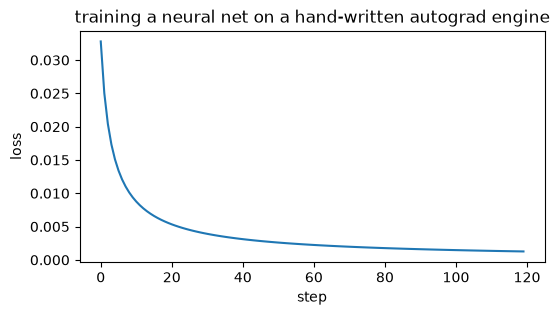

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3)); plt.plot(losses)
plt.title("training a neural net on a hand-written autograd engine"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import matplotlib.pyplot as plt</code>: the plotting toolbox.</li>
<li><code>plt.plot(losses)</code>: with a single list, matplotlib uses 0,1,2,... for the x-axis: loss per step, falling.</li>
<li>Title, axis labels, and <code>plt.show()</code>: the standard plotting finish.</li>
</ul>
</details>

### See what it learned: the decision boundary

The loss curve tells you training worked, but not *what* the net now believes. So feed a whole grid of points through the trained model and colour each region by the sign of the output. The eight training points fall on the right sides of a boundary the engine bent to fit them -- learned with nothing but the autograd we wrote at the top of this notebook.

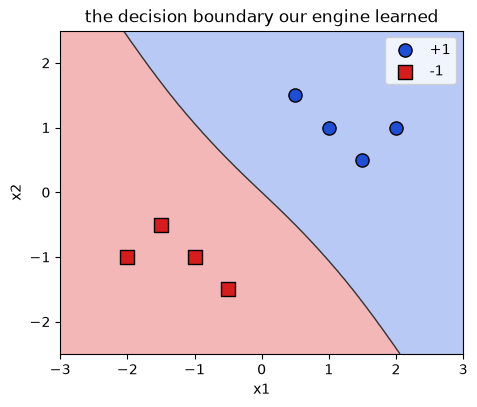

In [25]:
# Feed a grid of points through the trained net; colour each by the sign of its output.
xr = [-3 + 6 * i / 43 for i in range(44)]
yr = [-2.5 + 5 * j / 35 for j in range(36)]
Z = [[model([X, Y]).data for X in xr] for Y in yr]     # 1584 forward passes

plt.figure(figsize=(5.2, 4.2))
plt.contourf(xr, yr, Z, levels=[-100, 0, 100], colors=["#f4b7b7", "#b7c9f4"])
plt.contour(xr, yr, Z, levels=[0], colors=["#333"], linewidths=1)
plt.scatter([p[0] for p in xs[:4]], [p[1] for p in xs[:4]], c="#1c4fd6", edgecolors="k", s=90, label="+1")
plt.scatter([p[0] for p in xs[4:]], [p[1] for p in xs[4:]], c="#d61c1c", edgecolors="k", s=90, marker="s", label="-1")
plt.legend(); plt.title("the decision boundary our engine learned")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>xr, yr</code>: a grid of x and y coordinates covering the plot area.</li>
<li><code>Z = [[model([X, Y]).data ...]]</code>: run the trained net on every grid point -- 1584 forward passes -- and keep each output number.</li>
<li><code>plt.contourf(..., levels=[-100, 0, 100])</code>: paint the plane in two colours, split at output 0 -- the model's decision.</li>
<li><code>plt.contour(..., levels=[0])</code>: draw the boundary line itself, where the net switches from -1 to +1.</li>
<li><code>plt.scatter(...)</code>: the eight training points on top; each sits in the correctly coloured region, so the net separated the two classes.</li>
</ul>
</details>

## Recap

You have built **autograd**: a graph of operations that differentiates itself by multiplying local rates along the chain, and you trained a real, if tiny, neural network on top of it. PyTorch's `.backward()` is exactly this idea, generalized from single numbers to whole **tensors** (a tensor is just a grid of numbers, as in notebook 01) and written in fast, low-level code for speed. From here on we let the framework handle the bookkeeping, but you now know precisely what it is doing underneath.

Next, notebook 05 covers **self-attention**, the mechanism that lets a token look back over the whole context rather than just one character.